# ReAlign comparison

In [1]:
CLIP_MODEL = "ViT-bigG-14" 
CLIP_PRETRAINED = "laion2b_s39b_b160k"
MODEL_TAG = f"{CLIP_MODEL}___{CLIP_PRETRAINED}"
EMBEDDING_MODEL_NAME = MODEL_TAG

## Flickr30K

In [2]:
import sys
import os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, random_split
from tqdm import tqdm

sys.path.append(os.path.abspath(".."))

from subspace_alignment.subspace_alignment import (
    fit_subspace_alignment,
    apply_subspace_alignment,
    analyze_subspace_dimensions,
)

import torch
from dataset.flickr30k.dataloader_embeddings_with_labels import EmbeddingsDatasetWithLabels
from dataset.flickr30k.flickr_imagenet_utils import original_idx2class
from metrics.retrieval import retrieval
from analysis.modality_gap import compute_gap
from metrics.clustering import _clustering_metrics_two_modalities_flickr30k
import random
import numpy as np
import torch

seed = 123
g = torch.Generator().manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

/opt/anaconda3/envs/few_dim_modalitygap/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Define constants
# Set this before running the notebook if you want to switch embedding source.
# Example: EMBEDDING_MODEL_NAME = "ViT-B-32___laion2b_s34b_b79k"
dataset_name = "flickr30k"
precomputed_dir = f"/mnt/media/emanuele/few_dimensions/dataset/flickr30k/precomputed_embeddings_with_labels/{EMBEDDING_MODEL_NAME}"
mscoco_precomputed_dir = f"/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/{EMBEDDING_MODEL_NAME}/precomputed_train2017_clip_imagenet"
mscoco_precomputed_dir_test = f"/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/{EMBEDDING_MODEL_NAME}/precomputed_val2017_clip_imagenet"
# msrvtt_precomputed_dir = f"/mnt/media/emanuele/few_dimensions/dataset/msrvtt/{EMBEDDING_MODEL_NAME}_v2/precomputed_train"
# msrvtt_precomputed_dir_test = f"/mnt/media/emanuele/few_dimensions/dataset/msrvtt/{EMBEDDING_MODEL_NAME}_v2/precomputed_test"
device = "cuda:1" if torch.cuda.is_available() else "cpu"

# Let's get the data
dataset = EmbeddingsDatasetWithLabels(precomputed_dir=precomputed_dir, split_name="flickr30k")
print(f"embedding_model={EMBEDDING_MODEL_NAME}")
print(f"flickr_precomputed_dir={precomputed_dir}")


[Loaded] 31783 samples from /mnt/media/emanuele/few_dimensions/dataset/flickr30k/precomputed_embeddings_with_labels/ViT-bigG-14___laion2b_s39b_b160k
embedding_model=ViT-bigG-14___laion2b_s39b_b160k
flickr_precomputed_dir=/mnt/media/emanuele/few_dimensions/dataset/flickr30k/precomputed_embeddings_with_labels/ViT-bigG-14___laion2b_s39b_b160k


### Filter out data construct dataloaders
We need to filter out the classes with very few samples, this may make the classifier struggle.

Analyzing label distribution: 100%|██████████| 31783/31783 [00:00<00:00, 152822.02it/s]


Unique labels: 815
Total samples: 31783


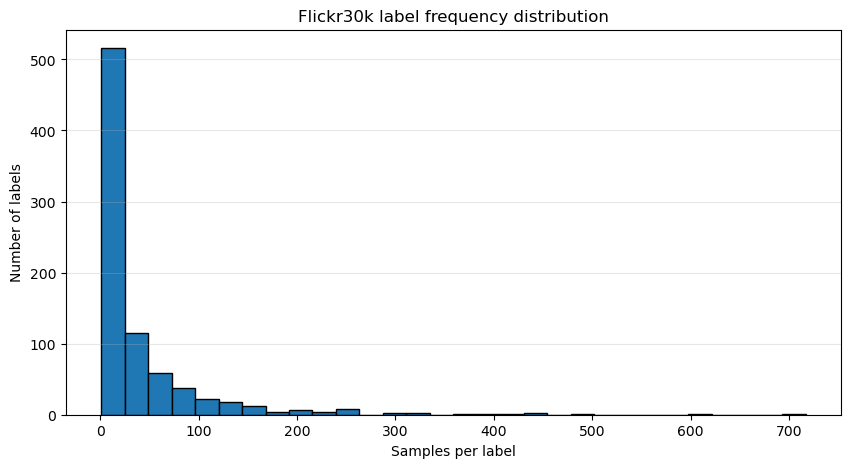

In [4]:
### Given the train_loader and the test_loader, discover how many unique labels are in the dataset, and how many samples per label. Plot the distribution of samples per label as a histogram.
def analyze_label_distribution(loader):
    label_counts = {}

    for batch in tqdm(loader, desc="Analyzing label distribution"):
        # Works for both Dataset samples and DataLoader batches
        if isinstance(batch, (list, tuple)) and len(batch) == 3:
            _, _, labels = batch
        else:
            continue

        if torch.is_tensor(labels):
            if labels.ndim == 0:  # single sample label (Dataset iteration)
                labels_iter = [int(labels.item())]
            else:  # batched labels (DataLoader iteration)
                labels_iter = labels.detach().cpu().view(-1).tolist()
        elif isinstance(labels, (list, tuple, np.ndarray)):
            labels_iter = np.asarray(labels).reshape(-1).tolist()
        else:
            labels_iter = [int(labels)]

        for lab in labels_iter:
            label_counts[lab] = label_counts.get(lab, 0) + 1

    return label_counts

label_counts = analyze_label_distribution(dataset)
print(f"Unique labels: {len(label_counts)}")
print(f"Total samples: {sum(label_counts.values())}")

# Histogram: distribution of "samples per label"
counts = list(label_counts.values())
plt.figure(figsize=(10, 5))
plt.hist(counts, bins=30, edgecolor="black")
plt.xlabel("Samples per label")
plt.ylabel("Number of labels")
plt.title("Flickr30k label frequency distribution")
plt.grid(axis="y", alpha=0.3)
plt.show()



In [5]:
# We should make sure to filter out classes that have too few samples, otherwise the classifier will struggle to learn. 
# Let's set a threshold of 1% of dataset total length as samples per class constraint.
# threshold = int(0.01 * len(dataset))
threshold = 10
print(f"Filtering out classes with less than {threshold} samples...")
class_counts = {}
for _, _, label in dataset:
    if label.item() not in class_counts:
        class_counts[label.item()] = 0
    class_counts[label.item()] += 1
    
filtered_classes = {cls for cls, count in class_counts.items() if count >= threshold}
print(f"Number of classes after filtering: {len(filtered_classes)}")
filtered_indices = [i for i, (_,_, label) in enumerate(dataset) if label.item() in filtered_classes]
filtered_dataset = torch.utils.data.Subset(dataset, filtered_indices)
print(f"Number of samples after filtering: {len(filtered_dataset)}")

Filtering out classes with less than 10 samples...
Number of classes after filtering: 465
Number of samples after filtering: 30471


In [6]:
# sort the class count by count value
class_counts = {cls: count for cls, count in class_counts.items() if cls in filtered_classes}
class_counts = dict(sorted(class_counts.items(), key=lambda item: item[1], reverse=True))
# print("Class counts after filtering:")
# for cls, count in class_counts.items():
#     print(f"Class {cls}: {count} samples")  

In [7]:
# Now split the filtered dataset into train and test only (stratified).
# We'll use a 80-20 split for train and test.
from sklearn.model_selection import train_test_split

# Extract labels for the filtered dataset
filtered_labels = []
for i in filtered_indices:
    _, _, label = dataset[i]
    filtered_labels.append(label.item())

filtered_labels = np.array(filtered_labels)

# Indices relative to filtered_dataset
all_indices = np.arange(len(filtered_dataset))

# Stratified split: Train (80%) and Test (20%)
train_idx, test_idx, _, _ = train_test_split(
    all_indices,
    filtered_labels,
    test_size=0.20,
    stratify=filtered_labels,
    random_state=seed
)

# Create final subsets
train_dataset = torch.utils.data.Subset(filtered_dataset, train_idx)
test_dataset = torch.utils.data.Subset(filtered_dataset, test_idx)

print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")


Train size: 24376
Test size: 6095


In [8]:
# check the class distribution in each split
def get_class_distribution(subset):
    class_counts = {}
    for _, _, label in subset:
        if label.item() not in class_counts:
            class_counts[label.item()] = 0
        class_counts[label.item()] += 1
    return class_counts

train_class_dist = get_class_distribution(train_dataset)
test_class_dist = get_class_distribution(test_dataset)

print("Number of classes in train set:", len(train_class_dist))
print("Number of classes in test set:", len(test_class_dist))
assert set(train_class_dist.keys()) == set(test_class_dist.keys()) and len(train_class_dist) == len(test_class_dist), "Train and test sets have different classes after filtering!"   
    

Number of classes in train set: 465
Number of classes in test set: 465


In [9]:
len_classes = len(train_class_dist)

# build a mapping from the original class indices to the new class indices after filtering
filtered_idx2class = {idx: val for idx, val in enumerate(sorted(train_class_dist.keys()))}
filtered_class2idx = {v: k for k, v in filtered_idx2class.items()}
new_idx2class = {idx: original_idx2class[val] for idx, val in filtered_idx2class.items()}
new_class2idx = {v: k for k, v in new_idx2class.items()}


In [10]:
# Now we can build the dataloaders for each split.
bs = 2048
train_dataloader = DataLoader(train_dataset, batch_size=bs, shuffle=True, generator=g)
test_dataloader = DataLoader(test_dataset, batch_size=bs, shuffle=False, generator=g)

In [11]:
# show training sample counts after filtering and splitting
train_label_counts = analyze_label_distribution(train_dataloader)
print(f"Unique labels in train set: {len(train_label_counts)}")
print(f"Total samples in train set: {sum(train_label_counts.values())}")

Analyzing label distribution:   0%|          | 0/12 [00:00<?, ?it/s]

Analyzing label distribution: 100%|██████████| 12/12 [00:00<00:00, 32.47it/s]

Unique labels in train set: 465
Total samples in train set: 24376


### Apply the realign method

Collect paired embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Collect paired embeddings: 100%|██████████| 3/3 [00:00<00:00, 35.84it/s]


=== REALIGN FLICKR30K RESULTS ===
direction=text_to_vision | n_fit=10000 | scale=0.948761
Retrieval original  : R@1=0.7431 | R@5=0.9037 | R@10=0.9436
Retrieval aligned   : R@1=0.6053 | R@5=0.8072 | R@10=0.8689
Gaps original       : {'L2M': 0.5777562260627747, 'L2I': 1.0676380395889282, 'cosineTP': 0.4291088581085205, 'RMG': 0.7652968789194688}
Gaps aligned        : {'L2M': 0.013882718048989773, 'L2I': 0.8711576461791992, 'cosineTP': 0.6179589033126831, 'RMG': 0.6970985770163032}
Clustering original : ARI=0.0675 | NMI=0.5561 | Hom=0.5778 | V=0.5561
Clustering aligned  : ARI=0.0833 | NMI=0.5779 | Hom=0.6004 | V=0.5779


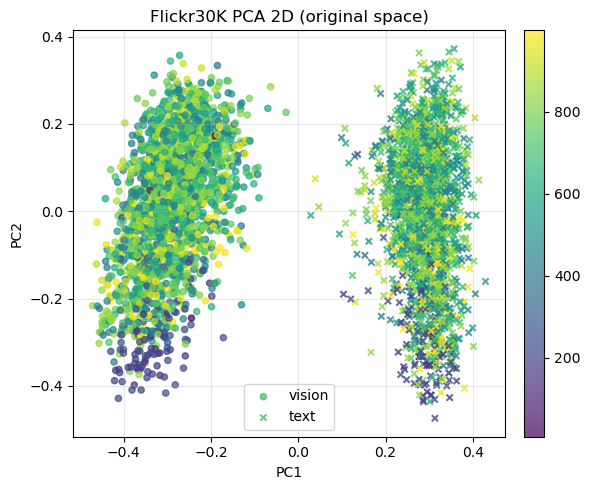

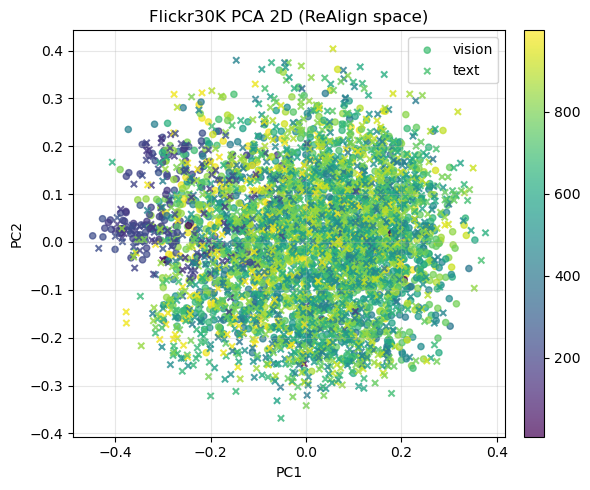

{'method': 'ReAlign',
 'direction': 'text_to_vision',
 'mapping': {'mu_t': tensor([ 0.0046,  0.0115, -0.0086,  ..., -0.0073, -0.0188,  0.0113]),
  'mu_i': tensor([-0.0026,  0.0061, -0.0022,  ..., -0.0080, -0.0247,  0.0083]),
  'mu_hat': tensor([-0.0026,  0.0061, -0.0022,  ..., -0.0081, -0.0247,  0.0083]),
  'scale': 0.9487608463341841,
  'n_fit': 10000,
  'trace_txt': 0.7377035013149907,
  'trace_img': 0.6640416995757681},
 'retrieval_orig': {1: 0.7430680990219116,
  5: 0.9036915898323059,
  10: 0.9435603022575378},
 'retrieval_aligned': {1: 0.6052502393722534,
  5: 0.8072190880775452,
  10: 0.8689090013504028},
 'gaps_orig': {'L2M': 0.5777562260627747,
  'L2I': 1.0676380395889282,
  'cosineTP': 0.4291088581085205,
  'RMG': 0.7652968789194688},
 'gaps_aligned': {'L2M': 0.013882718048989773,
  'L2I': 0.8711576461791992,
  'cosineTP': 0.6179589033126831,
  'RMG': 0.6970985770163032},
 'clustering_orig': {'ARI': 0.06753805573156949,
  'NMI': np.float64(0.5561196644076134),
  'Homogeneity'

In [12]:
# ReAlign implementation for Flickr30K: fit on train, evaluate on test.
from sklearn.decomposition import PCA

REALIGN_CFG = {
    "n_fit": 10_000,
    "max_cluster_samples": 5_000,
    "direction": "text_to_vision",
    "plot_pca": True,
}


def _to_scalar(v):
    if torch.is_tensor(v):
        v = v.item()
    if isinstance(v, dict):
        v = v.get("text_vision", next(iter(v.values())))
    return float(v)


def l2_normalize_np(x, eps=1e-10):
    x = np.asarray(x, dtype=np.float64)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    scale = np.max(np.abs(x), axis=1, keepdims=True)
    scale = np.where(scale > 0.0, scale, 1.0)

    x_scaled = x / scale
    norm_scaled = np.linalg.norm(x_scaled, axis=1, keepdims=True)
    norm = scale * norm_scaled
    norm = np.nan_to_num(norm, nan=0.0, posinf=0.0, neginf=0.0)
    norm = np.where(norm < eps, 1.0, norm)
    return x / norm


def collect_paired_embeddings(loader, max_samples=None, device="cpu"):
    text_buf, vision_buf, label_buf = [], [], []
    seen = 0

    with torch.no_grad():
        for text_b, vision_b, labels in tqdm(loader, desc="Collect paired embeddings"):
            text_b = F.normalize(text_b.to(device), dim=-1)
            vision_b = F.normalize(vision_b.to(device), dim=-1)
            labels = labels.to(device)

            if max_samples is not None:
                remaining = max_samples - seen
                if remaining <= 0:
                    break
                b = min(text_b.shape[0], remaining)
                text_b = text_b[:b]
                vision_b = vision_b[:b]
                labels = labels[:b]
                seen += b

            text_buf.append(text_b.detach().cpu())
            vision_buf.append(vision_b.detach().cpu())
            label_buf.append(labels.detach().cpu())

    if not text_buf:
        raise ValueError("No embeddings were collected from the dataloader.")

    text_all = torch.cat(text_buf, dim=0)
    vision_all = torch.cat(vision_buf, dim=0)
    labels_all = torch.cat(label_buf, dim=0)
    return text_all, vision_all, labels_all


def fit_realign_mapping(loader, n_fit=10_000, device="cpu"):
    X_t, Y_t, _ = collect_paired_embeddings(loader, max_samples=n_fit, device=device)

    X_np = l2_normalize_np(X_t.numpy())
    Y_np = l2_normalize_np(Y_t.numpy())

    mu_t = X_np.mean(axis=0)
    mu_i = Y_np.mean(axis=0)

    trace_txt = np.mean(np.sum((X_np - mu_t) ** 2, axis=1))
    trace_img = np.mean(np.sum((Y_np - mu_i) ** 2, axis=1))
    scale = float(np.sqrt(trace_img / (trace_txt + 1e-10)))

    X_hat = l2_normalize_np((X_np - mu_t) * scale + mu_i)
    mu_hat = X_hat.mean(axis=0)

    return {
        "mu_t": torch.from_numpy(mu_t.astype(np.float32)),
        "mu_i": torch.from_numpy(mu_i.astype(np.float32)),
        "mu_hat": torch.from_numpy(mu_hat.astype(np.float32)),
        "scale": scale,
        "n_fit": int(X_np.shape[0]),
        "trace_txt": float(trace_txt),
        "trace_img": float(trace_img),
    }


def apply_realign_mapping(text_embeddings, vision_embeddings, mapping, renorm=True):
    mu_t = mapping["mu_t"].to(device=text_embeddings.device, dtype=text_embeddings.dtype)
    mu_i = mapping["mu_i"].to(device=text_embeddings.device, dtype=text_embeddings.dtype)
    mu_hat = mapping["mu_hat"].to(device=text_embeddings.device, dtype=text_embeddings.dtype)
    scale = torch.as_tensor(mapping["scale"], device=text_embeddings.device, dtype=text_embeddings.dtype)

    X = F.normalize(text_embeddings, dim=-1)
    Y = F.normalize(vision_embeddings, dim=-1)

    X_hat = F.normalize((X - mu_t) * scale + mu_i, dim=-1)
    X_aligned = X_hat - mu_hat + mu_i

    if renorm:
        X_aligned = F.normalize(X_aligned, dim=-1)
        Y = F.normalize(Y, dim=-1)

    return X, Y, X_aligned


RMG_HIGH_DIM_THRESHOLD = 1024
RMG_REDUCED_BATCH_SIZE = 512


def _iter_rmg_subbatches(text_b, vision_b, extra=None, dim_threshold=RMG_HIGH_DIM_THRESHOLD, reduced_batch_size=RMG_REDUCED_BATCH_SIZE):
    embedding_dim = max(int(text_b.shape[-1]), int(vision_b.shape[-1]))
    if embedding_dim <= dim_threshold or text_b.shape[0] <= reduced_batch_size:
        yield text_b, vision_b, extra
        return

    for start in range(0, text_b.shape[0], reduced_batch_size):
        end = min(start + reduced_batch_size, text_b.shape[0])
        extra_chunk = None if extra is None else extra[start:end]
        yield text_b[start:end], vision_b[start:end], extra_chunk


def retrieval_flickr30k(X, Y, top_k=1):
    return float(retrieval(X, Y, top_k=top_k))


def plot_pca_flickr30k(emb_2N, labels_2N, title, max_points=4000):
    modality = np.concatenate([
        np.zeros(emb_2N.shape[0] // 2, dtype=np.int32),
        np.ones(emb_2N.shape[0] - emb_2N.shape[0] // 2, dtype=np.int32),
    ])

    if emb_2N.shape[0] > max_points:
        idx = np.random.RandomState(seed).choice(emb_2N.shape[0], size=max_points, replace=False)
        emb_2N = emb_2N[idx]
        labels_2N = labels_2N[idx]
        modality = modality[idx]

    z = PCA(n_components=2, random_state=seed).fit_transform(emb_2N)

    plt.figure(figsize=(6, 5))
    sc_vis = plt.scatter(
        z[modality == 1, 0], z[modality == 1, 1],
        c=labels_2N[modality == 1], s=20, marker="o", alpha=0.7, label="vision"
    )
    plt.scatter(
        z[modality == 0, 0], z[modality == 0, 1],
        c=labels_2N[modality == 0], s=20, marker="x", alpha=0.8,
        cmap=sc_vis.cmap, norm=sc_vis.norm, label="text"
    )
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")
    plt.colorbar(sc_vis, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def mean_rmg_over_batches(loader, mapping, direction="text_to_vision"):
    rmg_orig_batches = []
    rmg_aligned_batches = []

    with torch.no_grad():
        for text_b, vision_b, _ in tqdm(loader, desc="RMG over batches"):
            for text_chunk, vision_chunk, _ in _iter_rmg_subbatches(text_b, vision_b):
                X = text_chunk.to(device)
                Y = vision_chunk.to(device)
                Xn, Yn, Xaln = apply_realign_mapping(X, Y, mapping, renorm=True)

                if direction == "text_to_vision":
                    rmg_orig_batches.append(float(_to_scalar(compute_gap("RMG", Xn, Yn, iterations=None))))
                    rmg_aligned_batches.append(float(_to_scalar(compute_gap("RMG", Xaln, Yn, iterations=None))))
                elif direction == "vision_to_text":
                    rmg_orig_batches.append(float(_to_scalar(compute_gap("RMG", Yn, Xn, iterations=None))))
                    rmg_aligned_batches.append(float(_to_scalar(compute_gap("RMG", Yn, Xaln, iterations=None))))
                else:
                    raise ValueError(f"Unknown direction: {direction}")

    return {
        "orig": float(np.mean(rmg_orig_batches)),
        "aligned": float(np.mean(rmg_aligned_batches)),
    }


def eval_realign_flickr30k(
    test_loader,
    mapping,
    direction="text_to_vision",
    max_cluster_samples=5_000,
    n_clusters=None,
    plot_pca=True,
):
    gaps = ["L2M", "L2I", "cosineTP"]
    mean_rmg = mean_rmg_over_batches(test_loader, mapping, direction=direction)

    Xt_all, Xv_all, labels_all = collect_paired_embeddings(test_loader, device=device)
    X = Xt_all.to(device)
    Y = Xv_all.to(device)
    labels = labels_all.to(device)

    Xn, Yn, Xaln = apply_realign_mapping(X, Y, mapping, renorm=True)

    if direction == "text_to_vision":
        q_orig, t_orig = Xn, Yn
        q_al, t_al = Xaln, Yn
        cluster_text_orig, cluster_text_al = Xn, Xaln
        cluster_vision_orig, cluster_vision_al = Yn, Yn
        gaps_orig = {g: float(_to_scalar(compute_gap(g, Xn, Yn, iterations=None))) for g in gaps}
        gaps_aligned = {g: float(_to_scalar(compute_gap(g, Xaln, Yn, iterations=None))) for g in gaps}
        gaps_orig["RMG"] = mean_rmg["orig"]
        gaps_aligned["RMG"] = mean_rmg["aligned"]
    elif direction == "vision_to_text":
        q_orig, t_orig = Yn, Xn
        q_al, t_al = Yn, Xaln
        cluster_text_orig, cluster_text_al = Yn, Yn
        cluster_vision_orig, cluster_vision_al = Xn, Xaln
        gaps_orig = {g: float(_to_scalar(compute_gap(g, Yn, Xn, iterations=None))) for g in gaps}
        gaps_aligned = {g: float(_to_scalar(compute_gap(g, Yn, Xaln, iterations=None))) for g in gaps}
        gaps_orig["RMG"] = mean_rmg["orig"]
        gaps_aligned["RMG"] = mean_rmg["aligned"]
    else:
        raise ValueError(f"Unknown direction: {direction}")

    retrieval_orig = {
        1: retrieval_flickr30k(q_orig, t_orig, top_k=1),
        5: retrieval_flickr30k(q_orig, t_orig, top_k=5),
        10: retrieval_flickr30k(q_orig, t_orig, top_k=10),
    }
    retrieval_aligned = {
        1: retrieval_flickr30k(q_al, t_al, top_k=1),
        5: retrieval_flickr30k(q_al, t_al, top_k=5),
        10: retrieval_flickr30k(q_al, t_al, top_k=10),
    }

    cluster_limit = min(int(max_cluster_samples), Xn.shape[0])
    clustering_orig = _clustering_metrics_two_modalities_flickr30k(
        cluster_text_orig[:cluster_limit].detach().cpu(),
        cluster_vision_orig[:cluster_limit].detach().cpu(),
        labels[:cluster_limit].detach().cpu(),
        n_clusters=n_clusters,
    )
    clustering_aligned = _clustering_metrics_two_modalities_flickr30k(
        cluster_text_al[:cluster_limit].detach().cpu(),
        cluster_vision_al[:cluster_limit].detach().cpu(),
        labels[:cluster_limit].detach().cpu(),
        n_clusters=n_clusters,
    )

    out = {
        "method": "ReAlign",
        "direction": direction,
        "mapping": mapping,
        "retrieval_orig": retrieval_orig,
        "retrieval_aligned": retrieval_aligned,
        "gaps_orig": gaps_orig,
        "gaps_aligned": gaps_aligned,
        "clustering_orig": clustering_orig,
        "clustering_aligned": clustering_aligned,
    }

    print("=== REALIGN FLICKR30K RESULTS ===")
    print(f"direction={direction} | n_fit={mapping['n_fit']} | scale={mapping['scale']:.6f}")
    print(
        "Retrieval original  : "
        f"R@1={retrieval_orig[1]:.4f} | R@5={retrieval_orig[5]:.4f} | R@10={retrieval_orig[10]:.4f}"
    )
    print(
        "Retrieval aligned   : "
        f"R@1={retrieval_aligned[1]:.4f} | R@5={retrieval_aligned[5]:.4f} | R@10={retrieval_aligned[10]:.4f}"
    )
    print("Gaps original       :", gaps_orig)
    print("Gaps aligned        :", gaps_aligned)
    print(
        "Clustering original : "
        f"ARI={clustering_orig['ARI']:.4f} | NMI={clustering_orig['NMI']:.4f} | "
        f"Hom={clustering_orig['Homogeneity']:.4f} | V={clustering_orig['V-measure']:.4f}"
    )
    print(
        "Clustering aligned  : "
        f"ARI={clustering_aligned['ARI']:.4f} | NMI={clustering_aligned['NMI']:.4f} | "
        f"Hom={clustering_aligned['Homogeneity']:.4f} | V={clustering_aligned['V-measure']:.4f}"
    )

    if plot_pca:
        labels_np = labels.detach().cpu().numpy()
        emb_orig = torch.cat([cluster_text_orig[:cluster_limit], cluster_vision_orig[:cluster_limit]], dim=0).detach().cpu().numpy()
        emb_al = torch.cat([cluster_text_al[:cluster_limit], cluster_vision_al[:cluster_limit]], dim=0).detach().cpu().numpy()
        labels_2n = np.concatenate([labels_np[:cluster_limit], labels_np[:cluster_limit]], axis=0)

        plot_pca_flickr30k(emb_orig, labels_2n, title="Flickr30K PCA 2D (original space)", max_points=min(4000, 2 * cluster_limit))
        plot_pca_flickr30k(emb_al, labels_2n, title="Flickr30K PCA 2D (ReAlign space)", max_points=min(4000, 2 * cluster_limit))

    return out


realign_mapping = fit_realign_mapping(
    train_dataloader,
    n_fit=REALIGN_CFG["n_fit"],
    device=device,
)

results_realign_flickr30k = eval_realign_flickr30k(
    test_dataloader,
    realign_mapping,
    direction=REALIGN_CFG["direction"],
    max_cluster_samples=REALIGN_CFG["max_cluster_samples"],
    n_clusters=len(train_class_dist),
    plot_pca=REALIGN_CFG["plot_pca"],
)

results_realign_flickr30k


## MSCOCO

In [13]:
print(f"embedding_model={EMBEDDING_MODEL_NAME}")
print(f"mscoco_precomputed_dir={mscoco_precomputed_dir}")
print(f"mscoco_precomputed_dir_test={mscoco_precomputed_dir_test}")

from dataset.mscoco.mscoco_dataloader_with_imagenet_labels import (
    MSCOCOEmbeddingsDatasetWithImageNetLabels,
    mscoco_imagenet_collate_fn,
)
from metrics.retrieval import compute_retrieval
from metrics.clustering import clustering_metrics_two_modalities_mscoco_imagenet_labels

MSCOCO_IMAGENET_CFG = {
    "n_fit": 10_000,
    "batch_size": 256,
    "max_eval_batches": None,
    "max_cluster_samples": 3_000,
    "direction": "text_to_vision",
    "plot_pca": True,
}

mscoco_dataset_name = "mscoco_imagenet_labels"

mscoco_train = MSCOCOEmbeddingsDatasetWithImageNetLabels(
    mscoco_precomputed_dir,
    split_name="train_shard",
    return_label_name=False,
)
mscoco_test = MSCOCOEmbeddingsDatasetWithImageNetLabels(
    mscoco_precomputed_dir_test,
    split_name="val_shard",
    return_label_name=False,
)


def _count_labels_dataset(dataset):
    counts = {}
    for i in range(len(dataset)):
        _, _, y = dataset[i]
        y = int(y.item()) if torch.is_tensor(y) else int(y)
        counts[y] = counts.get(y, 0) + 1
    return counts


train_counts = _count_labels_dataset(mscoco_train)
test_counts = _count_labels_dataset(mscoco_test)

test_classes = set(test_counts.keys())
keep_classes = {c for c in test_classes if train_counts.get(c, 0) >= 10}

train_indices = [
    i for i in range(len(mscoco_train))
    if int(mscoco_train[i][2].item()) in keep_classes
]
test_indices = [
    i for i in range(len(mscoco_test))
    if int(mscoco_test[i][2].item()) in keep_classes
]

filtered_train_mscoco = torch.utils.data.Subset(mscoco_train, train_indices)
filtered_test_mscoco = torch.utils.data.Subset(mscoco_test, test_indices)

filtered_train_counts = _count_labels_dataset(filtered_train_mscoco)
filtered_test_counts = _count_labels_dataset(filtered_test_mscoco)

train_classes_mscoco = set(filtered_train_counts.keys())
test_classes_mscoco = set(filtered_test_counts.keys())

print(f"Kept classes (train >= 10 & in test): {len(keep_classes)}")
print(f"Train classes after filter: {len(train_classes_mscoco)}")
print(f"Test classes after filter: {len(test_classes_mscoco)}")
print(f"Train samples after filter: {len(filtered_train_mscoco)}")
print(f"Test samples after filter: {len(filtered_test_mscoco)}")

assert train_classes_mscoco == test_classes_mscoco, "Train/test class mismatch after filtering"

N_CLUSTERS_MSCOCO_IMAGENET = len(train_classes_mscoco)

train_loader_mscoco = DataLoader(
    filtered_train_mscoco,
    batch_size=MSCOCO_IMAGENET_CFG["batch_size"],
    shuffle=True,
    num_workers=0,
    collate_fn=mscoco_imagenet_collate_fn,
)
test_loader_mscoco = DataLoader(
    filtered_test_mscoco,
    batch_size=MSCOCO_IMAGENET_CFG["batch_size"],
    shuffle=False,
    num_workers=0,
    collate_fn=mscoco_imagenet_collate_fn,
)


embedding_model=ViT-bigG-14___laion2b_s39b_b160k
mscoco_precomputed_dir=/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/ViT-bigG-14___laion2b_s39b_b160k/precomputed_train2017_clip_imagenet
mscoco_precomputed_dir_test=/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/ViT-bigG-14___laion2b_s39b_b160k/precomputed_val2017_clip_imagenet
[Loaded COCO ImageNet] 118287 samples from /mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/ViT-bigG-14___laion2b_s39b_b160k/precomputed_train2017_clip_imagenet | vision_emb shape=(118287, 1280)
[Loaded COCO ImageNet] 5000 samples from /mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/ViT-bigG-14___laion2b_s39b_b160k/precomputed_val2017_clip_imagenet | vision_emb shape=(5000, 1280)
Kept classes (train >= 10 & in test): 517
Train classes after filter: 517
Test classes after filter: 517
Train samples after filter: 113777
Test samples after filter: 4963


Collect paired embeddings:   0%|          | 0/445 [00:00<?, ?it/s]

Accumulate MSCOCO ImageNet test set: 100%|██████████| 20/20 [00:00<00:00, 300.22it/s]


=== REALIGN MSCOCO + IMAGENET LABELS RESULTS ===
direction=text_to_vision | n_fit=10000 | scale=0.957825
Retrieval original  : R@1=0.4699 | R@5=0.7242 | R@10=0.8080
Retrieval aligned   : R@1=0.3625 | R@5=0.5940 | R@10=0.6907
Mean RMG over batches: {'orig': 0.771183070016002, 'aligned': 0.701134452809342}
Gaps original       : {'L2M': 0.6012502312660217, 'L2I': 1.092373251914978, 'cosineTP': 0.4021919369697571, 'RMG': 0.771183070016002}
Gaps aligned        : {'L2M': 0.015878641977906227, 'L2I': 0.8887238502502441, 'cosineTP': 0.601878821849823, 'RMG': 0.701134452809342}
Clustering original : ARI=0.1460 | NMI=0.6841 | Hom=0.7407 | V=0.6841
Clustering aligned  : ARI=0.1487 | NMI=0.6965 | Hom=0.7547 | V=0.6965


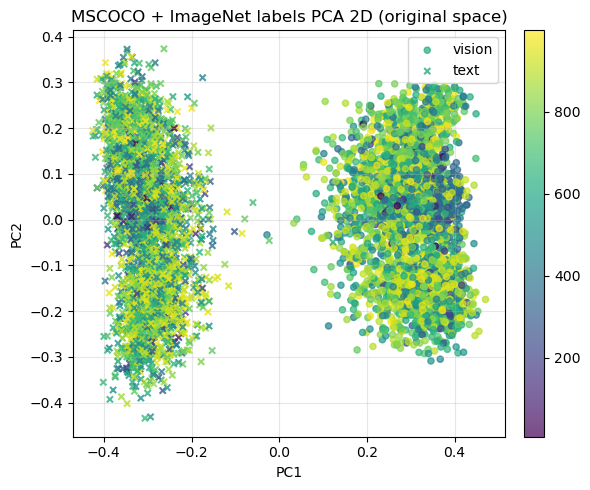

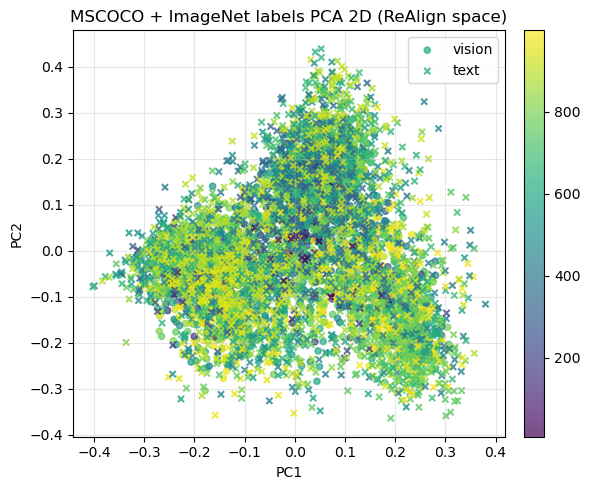

{'method': 'ReAlign',
 'dataset': 'mscoco_imagenet_labels',
 'direction': 'text_to_vision',
 'mapping': {'mu_t': tensor([ 0.0120,  0.0133, -0.0083,  ..., -0.0117, -0.0281,  0.0118]),
  'mu_i': tensor([ 0.0013,  0.0059, -0.0040,  ..., -0.0100, -0.0215,  0.0071]),
  'mu_hat': tensor([ 0.0014,  0.0059, -0.0039,  ..., -0.0101, -0.0214,  0.0072]),
  'scale': 0.9578247028741557,
  'n_fit': 10000,
  'trace_txt': 0.7399011430121561,
  'trace_img': 0.6788061453697539},
 'retrieval_orig': {1: 0.46987709403038025,
  5: 0.724158763885498,
  10: 0.8079790472984314},
 'retrieval_aligned': {1: 0.36248236894607544,
  5: 0.5939955711364746,
  10: 0.690711259841919},
 'gaps_orig': {'L2M': 0.6012502312660217,
  'L2I': 1.092373251914978,
  'cosineTP': 0.4021919369697571,
  'RMG': 0.771183070016002},
 'gaps_aligned': {'L2M': 0.015878641977906227,
  'L2I': 0.8887238502502441,
  'cosineTP': 0.601878821849823,
  'RMG': 0.701134452809342},
 'mean_rmg_over_batches': {'orig': 0.771183070016002,
  'aligned': 0.70

In [14]:
def mean_rmg_over_batches_mscoco_imagenet(loader, mapping, direction="text_to_vision", max_eval_batches=None):
    rmg_orig_batches = []
    rmg_aligned_batches = []
    n_batches = 0

    with torch.no_grad():
        for text_b, vis_b, _ in tqdm(loader, desc="MSCOCO ImageNet RMG over batches"):
            for text_chunk, vision_chunk, _ in _iter_rmg_subbatches(text_b, vis_b):
                X = text_chunk.to(device)
                Y = vision_chunk.to(device)
                Xn, Yn, Xaln = apply_realign_mapping(X, Y, mapping, renorm=True)

                if direction == "text_to_vision":
                    rmg_orig_batches.append(float(_to_scalar(compute_gap("RMG", Xn, Yn, iterations=None))))
                    rmg_aligned_batches.append(float(_to_scalar(compute_gap("RMG", Xaln, Yn, iterations=None))))
                elif direction == "vision_to_text":
                    rmg_orig_batches.append(float(_to_scalar(compute_gap("RMG", Yn, Xn, iterations=None))))
                    rmg_aligned_batches.append(float(_to_scalar(compute_gap("RMG", Yn, Xaln, iterations=None))))
                else:
                    raise ValueError(f"Unknown direction: {direction}")

            n_batches += 1
            if max_eval_batches is not None and n_batches >= max_eval_batches:
                break

    return {
        "orig": float(np.mean(rmg_orig_batches)),
        "aligned": float(np.mean(rmg_aligned_batches)),
    }


def eval_realign_mscoco_imagenet(
    test_loader,
    mapping,
    direction="text_to_vision",
    max_eval_batches=None,
    max_cluster_samples=3_000,
    n_clusters=None,
    plot_pca=True,
):
    gaps = ["L2M", "L2I", "cosineTP"]
    mean_rmg = mean_rmg_over_batches_mscoco_imagenet(
        test_loader,
        mapping,
        direction=direction,
        max_eval_batches=max_eval_batches,
    )

    X_buf, Y_buf, y_buf = [], [], []
    n_batches = 0

    with torch.no_grad():
        for text_b, vis_b, labels in tqdm(test_loader, desc="Accumulate MSCOCO ImageNet test set"):
            X = F.normalize(text_b, dim=-1).cpu()
            Y = F.normalize(vis_b, dim=-1).cpu()
            labels = labels if torch.is_tensor(labels) else torch.as_tensor(labels)
            labels = labels.cpu()

            X_buf.append(X)
            Y_buf.append(Y)
            y_buf.append(labels)

            n_batches += 1
            if max_eval_batches is not None and n_batches >= max_eval_batches:
                break

    if len(X_buf) == 0:
        raise ValueError("No samples were accumulated from test_loader.")

    X_all = torch.cat(X_buf, dim=0)
    Y_all = torch.cat(Y_buf, dim=0)
    y_all = torch.cat(y_buf, dim=0)

    if direction == "text_to_vision":
        q_orig_all, t_orig_all = X_all, Y_all
    elif direction == "vision_to_text":
        q_orig_all, t_orig_all = Y_all, X_all
    else:
        raise ValueError(f"Unknown direction: {direction}")

    retrieval_orig = {
        1: float(_to_scalar(compute_retrieval(mscoco_dataset_name, (q_orig_all, t_orig_all), top_k=1))),
        5: float(_to_scalar(compute_retrieval(mscoco_dataset_name, (q_orig_all, t_orig_all), top_k=5))),
        10: float(_to_scalar(compute_retrieval(mscoco_dataset_name, (q_orig_all, t_orig_all), top_k=10))),
    }

    if direction == "text_to_vision":
        gaps_orig = {g: float(_to_scalar(compute_gap(g, X_all, Y_all, iterations=None))) for g in gaps}
    else:
        gaps_orig = {g: float(_to_scalar(compute_gap(g, Y_all, X_all, iterations=None))) for g in gaps}
    gaps_orig["RMG"] = mean_rmg["orig"]

    align_bs = 1024
    q_al_chunks, t_al_chunks = [], []

    with torch.no_grad():
        for s in range(0, X_all.shape[0], align_bs):
            e = min(s + align_bs, X_all.shape[0])
            xb = X_all[s:e].to(device)
            yb = Y_all[s:e].to(device)
            Xn, Yn, Xaln = apply_realign_mapping(xb, yb, mapping, renorm=True)

            if direction == "text_to_vision":
                q_al_chunks.append(Xaln.detach().cpu())
                t_al_chunks.append(Yn.detach().cpu())
            else:
                q_al_chunks.append(Yn.detach().cpu())
                t_al_chunks.append(Xaln.detach().cpu())

    q_al_all = torch.cat(q_al_chunks, dim=0)
    t_al_all = torch.cat(t_al_chunks, dim=0)

    retrieval_aligned = {
        1: float(_to_scalar(compute_retrieval(mscoco_dataset_name, (q_al_all, t_al_all), top_k=1))),
        5: float(_to_scalar(compute_retrieval(mscoco_dataset_name, (q_al_all, t_al_all), top_k=5))),
        10: float(_to_scalar(compute_retrieval(mscoco_dataset_name, (q_al_all, t_al_all), top_k=10))),
    }

    gaps_aligned = {g: float(_to_scalar(compute_gap(g, q_al_all, t_al_all, iterations=None))) for g in gaps}
    gaps_aligned["RMG"] = mean_rmg["aligned"]

    if n_clusters is None:
        raise ValueError("n_clusters must be specified for MSCOCO ImageNet clustering evaluation")

    if max_cluster_samples is not None and X_all.shape[0] > max_cluster_samples:
        sel = torch.randperm(X_all.shape[0])[:max_cluster_samples]
        q_orig_c = q_orig_all[sel]
        t_orig_c = t_orig_all[sel]
        q_al_c = q_al_all[sel]
        t_al_c = t_al_all[sel]
        y_c = y_all[sel]
    else:
        q_orig_c = q_orig_all
        t_orig_c = t_orig_all
        q_al_c = q_al_all
        t_al_c = t_al_all
        y_c = y_all

    clustering_orig = clustering_metrics_two_modalities_mscoco_imagenet_labels(
        q_orig_c,
        t_orig_c,
        y_c,
        n_clusters=n_clusters,
        random_state=0,
    )
    clustering_aligned = clustering_metrics_two_modalities_mscoco_imagenet_labels(
        q_al_c,
        t_al_c,
        y_c,
        n_clusters=n_clusters,
        random_state=0,
    )

    out = {
        "method": "ReAlign",
        "dataset": mscoco_dataset_name,
        "direction": direction,
        "mapping": mapping,
        "retrieval_orig": retrieval_orig,
        "retrieval_aligned": retrieval_aligned,
        "gaps_orig": gaps_orig,
        "gaps_aligned": gaps_aligned,
        "mean_rmg_over_batches": mean_rmg,
        "clustering_orig": clustering_orig,
        "clustering_aligned": clustering_aligned,
    }

    print("=== REALIGN MSCOCO + IMAGENET LABELS RESULTS ===")
    print(f"direction={direction} | n_fit={mapping['n_fit']} | scale={mapping['scale']:.6f}")
    print(
        "Retrieval original  : "
        f"R@1={retrieval_orig[1]:.4f} | R@5={retrieval_orig[5]:.4f} | R@10={retrieval_orig[10]:.4f}"
    )
    print(
        "Retrieval aligned   : "
        f"R@1={retrieval_aligned[1]:.4f} | R@5={retrieval_aligned[5]:.4f} | R@10={retrieval_aligned[10]:.4f}"
    )
    print("Mean RMG over batches:", mean_rmg)
    print("Gaps original       :", gaps_orig)
    print("Gaps aligned        :", gaps_aligned)
    print(
        "Clustering original : "
        f"ARI={clustering_orig['ARI']:.4f} | NMI={clustering_orig['NMI']:.4f} | "
        f"Hom={clustering_orig['Homogeneity']:.4f} | V={clustering_orig['V-measure']:.4f}"
    )
    print(
        "Clustering aligned  : "
        f"ARI={clustering_aligned['ARI']:.4f} | NMI={clustering_aligned['NMI']:.4f} | "
        f"Hom={clustering_aligned['Homogeneity']:.4f} | V={clustering_aligned['V-measure']:.4f}"
    )

    if plot_pca:
        labels_np = y_c.detach().cpu().numpy()
        emb_orig = torch.cat([q_orig_c, t_orig_c], dim=0).detach().cpu().numpy()
        emb_al = torch.cat([q_al_c, t_al_c], dim=0).detach().cpu().numpy()
        labels_2n = np.concatenate([labels_np, labels_np], axis=0)
        plot_pca_flickr30k(emb_orig, labels_2n, title="MSCOCO + ImageNet labels PCA 2D (original space)", max_points=min(6000, emb_orig.shape[0]))
        plot_pca_flickr30k(emb_al, labels_2n, title="MSCOCO + ImageNet labels PCA 2D (ReAlign space)", max_points=min(6000, emb_al.shape[0]))

    return out


realign_mapping_mscoco_imagenet = fit_realign_mapping(
    train_loader_mscoco,
    n_fit=MSCOCO_IMAGENET_CFG["n_fit"],
    device=device,
)

results_realign_mscoco_imagenet = eval_realign_mscoco_imagenet(
    test_loader_mscoco,
    realign_mapping_mscoco_imagenet,
    direction=MSCOCO_IMAGENET_CFG["direction"],
    max_eval_batches=MSCOCO_IMAGENET_CFG["max_eval_batches"],
    max_cluster_samples=MSCOCO_IMAGENET_CFG["max_cluster_samples"],
    n_clusters=N_CLUSTERS_MSCOCO_IMAGENET,
    plot_pca=MSCOCO_IMAGENET_CFG["plot_pca"],
)

results_realign_mscoco_imagenet


## MSRVTT

In [ ]:
print(f"embedding_model={EMBEDDING_MODEL_NAME}")
print(f"msrvtt_precomputed_dir={msrvtt_precomputed_dir}")
print(f"msrvtt_precomputed_dir_test={msrvtt_precomputed_dir_test}")

from dataset.msrvtt.msrvtt_dataloaderv2 import (
    MSRVTTEmbeddingsDatasetV2,
    msrvtt_v2_collate_fn,
)
from metrics.clustering import clustering_metrics_two_modalities_msrvtt

MSRVTT_CFG = {
    "n_fit": 10_000,
    "batch_size": 256,
    "num_workers": 0,
    "max_eval_batches": None,
    "max_cluster_samples": 3_000,
    "direction": "text_to_vision",
    "plot_pca": True,
    "n_clusters": 20,
}

msrvtt_dataset_name = "msrvtt"

msrvtt_train = MSRVTTEmbeddingsDatasetV2(
    msrvtt_precomputed_dir,
    split_name="train_shard",
    return_metadata=False,
)
msrvtt_test = MSRVTTEmbeddingsDatasetV2(
    msrvtt_precomputed_dir_test,
    split_name="test_shard",
    return_metadata=False,
)

train_loader_msrvtt = DataLoader(
    msrvtt_train,
    batch_size=MSRVTT_CFG["batch_size"],
    shuffle=True,
    num_workers=MSRVTT_CFG["num_workers"],
    collate_fn=msrvtt_v2_collate_fn,
    generator=g,
)
test_loader_msrvtt = DataLoader(
    msrvtt_test,
    batch_size=MSRVTT_CFG["batch_size"],
    shuffle=False,
    num_workers=MSRVTT_CFG["num_workers"],
    collate_fn=msrvtt_v2_collate_fn,
)

print(f"Train samples (v2): {len(msrvtt_train)}")
print(f"Test samples  (v2): {len(msrvtt_test)}")


[MSRVTTv2] 7010 unique videos from /mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k_v2/precomputed_train | vision_emb=(7010, 512) | text_emb=(7010, 512) | num_classes=20
[MSRVTTv2] 1000 unique videos from /mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k_v2/precomputed_test | vision_emb=(1000, 512) | text_emb=(1000, 512) | num_classes=20
Train samples (v2): 7010
Test samples  (v2): 1000


Accumulate MSRVTT v2 test set: 100%|██████████| 4/4 [00:00<00:00, 498.92it/s]


=== REALIGN MSRVTT v2 RESULTS ===
direction=text_to_vision | n_fit=7010 | scale=1.011969
Retrieval original  : R@1=0.3260 | R@5=0.5790 | R@10=0.6860
Retrieval aligned   : R@1=0.2090 | R@5=0.3990 | R@10=0.5040
Mean RMG over batches: {'orig': 0.8380064854349313, 'aligned': 0.7493886652570739}
Gaps original       : {'L2M': 0.7806441187858582, 'L2I': 1.1991440057754517, 'cosineTP': 0.2800264060497284, 'RMG': 0.8380064854349313}
Gaps aligned        : {'L2M': 0.05111632123589516, 'L2I': 0.9137681722640991, 'cosineTP': 0.579486072063446, 'RMG': 0.7493886652570739}
Clustering original : ARI=0.1128 | NMI=0.2448 | Hom=0.2474 | V=0.2448
Clustering aligned  : ARI=0.1711 | NMI=0.2976 | Hom=0.2994 | V=0.2976


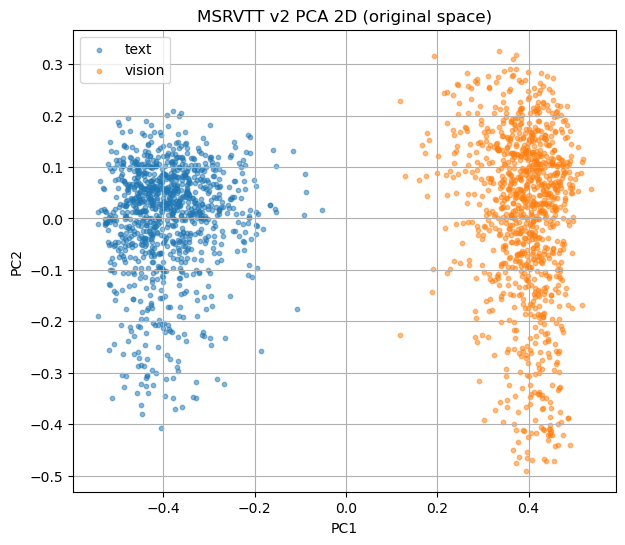

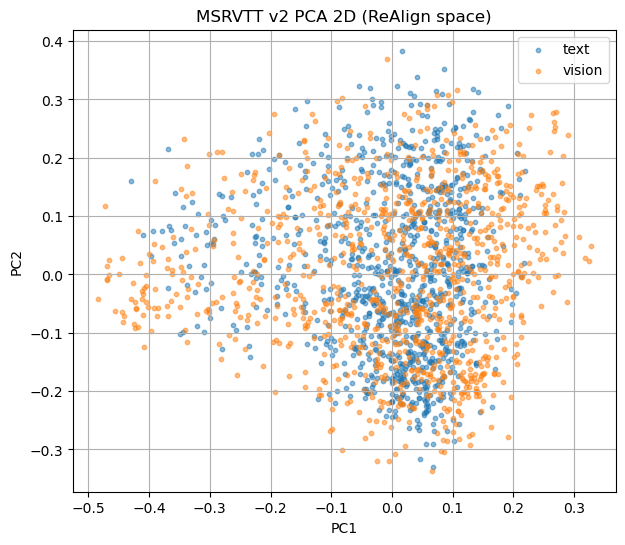

{'method': 'ReAlign',
 'dataset': 'msrvtt',
 'direction': 'text_to_vision',
 'mapping': {'mu_t': tensor([-1.5084e-02, -7.7525e-03, -6.6306e-03, -7.6190e-03, -1.7589e-02,
          -1.2404e-02, -1.0659e-02, -2.2356e-03, -7.1603e-03, -7.1023e-03,
          -5.1532e-04, -1.8667e-03,  1.0645e-02,  8.4115e-03, -9.6162e-03,
           2.6390e-03, -5.5873e-02, -1.0426e-02, -1.5400e-02,  3.7802e-03,
           7.0478e-03,  2.3584e-02,  1.4294e-02, -3.1586e-03, -1.0658e-02,
           1.9002e-03, -2.6322e-04,  8.1660e-03,  1.3279e-02,  1.0154e-02,
          -1.1804e-02, -1.4202e-02,  9.9129e-03, -2.9513e-04,  1.2858e-02,
           2.2968e-03,  2.7598e-03,  1.5087e-02, -9.3987e-04, -8.3502e-03,
          -6.3749e-03, -7.2495e-03, -7.2497e-03,  1.2482e-02,  2.1393e-02,
           1.0208e-02, -2.7213e-02,  6.2116e-04,  3.7235e-03,  1.3685e-03,
          -6.4349e-03,  1.3257e-02,  1.0669e-02,  1.3256e-02,  1.5293e-03,
          -6.5969e-03, -3.0640e-04,  1.7828e-03, -9.8125e-03,  4.5644e-03,
     

In [ ]:
def mean_rmg_over_batches_msrvtt(loader, mapping, direction="text_to_vision", max_eval_batches=None):
    rmg_orig_batches = []
    rmg_aligned_batches = []
    n_batches = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="MSRVTT v2 RMG over batches"):
            text_b, vis_b = batch[:2]
            for text_chunk, vision_chunk, _ in _iter_rmg_subbatches(text_b, vis_b):
                X = text_chunk.to(device)
                Y = vision_chunk.to(device)
                Xn, Yn, Xaln = apply_realign_mapping(X, Y, mapping, renorm=True)

                if direction == "text_to_vision":
                    rmg_orig_batches.append(float(_to_scalar(compute_gap("RMG", Xn, Yn, iterations=None))))
                    rmg_aligned_batches.append(float(_to_scalar(compute_gap("RMG", Xaln, Yn, iterations=None))))
                elif direction == "vision_to_text":
                    rmg_orig_batches.append(float(_to_scalar(compute_gap("RMG", Yn, Xn, iterations=None))))
                    rmg_aligned_batches.append(float(_to_scalar(compute_gap("RMG", Yn, Xaln, iterations=None))))
                else:
                    raise ValueError(f"Unknown direction: {direction}")

            n_batches += 1
            if max_eval_batches is not None and n_batches >= max_eval_batches:
                break

    return {
        "orig": float(np.mean(rmg_orig_batches)),
        "aligned": float(np.mean(rmg_aligned_batches)),
    }


def _plot_pca_2d_modalities_realign(emb, modality_labels, title, max_points=4000):
    if emb.shape[0] > max_points:
        idx = np.random.RandomState(seed).choice(emb.shape[0], max_points, replace=False)
        emb = emb[idx]
        modality_labels = modality_labels[idx]

    z = PCA(n_components=2, random_state=seed).fit_transform(emb)

    plt.figure(figsize=(7, 6))
    for modality in np.unique(modality_labels):
        mask = modality_labels == modality
        plt.scatter(z[mask, 0], z[mask, 1], s=10, alpha=0.5, label=modality)

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.legend()
    plt.show()


def eval_realign_msrvtt(
    test_loader,
    mapping,
    direction="text_to_vision",
    max_eval_batches=None,
    max_cluster_samples=3_000,
    n_clusters=20,
    plot_pca=True,
):
    gaps = ["L2M", "L2I", "cosineTP"]
    mean_rmg = mean_rmg_over_batches_msrvtt(
        test_loader,
        mapping,
        direction=direction,
        max_eval_batches=max_eval_batches,
    )

    Xt_buf, Xv_buf, Xt_al_buf, Xv_al_buf, labels_buf = [], [], [], [], []
    n_batches = 0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Accumulate MSRVTT v2 test set"):
            text_b, vis_b = batch[:2]
            labels = batch[2] if len(batch) > 2 else None

            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)
            Xn, Yn, Xaln = apply_realign_mapping(X, Y, mapping, renorm=True)

            if direction == "text_to_vision":
                q_orig_b, t_orig_b = Xn, Yn
                q_al_b, t_al_b = Xaln, Yn
            elif direction == "vision_to_text":
                q_orig_b, t_orig_b = Yn, Xn
                q_al_b, t_al_b = Yn, Xaln
            else:
                raise ValueError(f"Unknown direction: {direction}")

            Xt_buf.append(q_orig_b.detach().cpu())
            Xv_buf.append(t_orig_b.detach().cpu())
            Xt_al_buf.append(q_al_b.detach().cpu())
            Xv_al_buf.append(t_al_b.detach().cpu())

            if labels is not None:
                labels_buf.append(torch.as_tensor(labels).detach().cpu())

            n_batches += 1
            if max_eval_batches is not None and n_batches >= max_eval_batches:
                break

    Xt_all = torch.cat(Xt_buf, dim=0)
    Xv_all = torch.cat(Xv_buf, dim=0)
    Xt_al_all = torch.cat(Xt_al_buf, dim=0)
    Xv_al_all = torch.cat(Xv_al_buf, dim=0)

    labels_all = None
    if len(labels_buf) > 0:
        labels_all = torch.cat(labels_buf, dim=0)

    retrieval_orig = {
        1: float(_to_scalar(compute_retrieval(msrvtt_dataset_name, (Xt_all, Xv_all), top_k=1))),
        5: float(_to_scalar(compute_retrieval(msrvtt_dataset_name, (Xt_all, Xv_all), top_k=5))),
        10: float(_to_scalar(compute_retrieval(msrvtt_dataset_name, (Xt_all, Xv_all), top_k=10))),
    }
    retrieval_aligned = {
        1: float(_to_scalar(compute_retrieval(msrvtt_dataset_name, (Xt_al_all, Xv_al_all), top_k=1))),
        5: float(_to_scalar(compute_retrieval(msrvtt_dataset_name, (Xt_al_all, Xv_al_all), top_k=5))),
        10: float(_to_scalar(compute_retrieval(msrvtt_dataset_name, (Xt_al_all, Xv_al_all), top_k=10))),
    }

    gaps_orig = {g: float(_to_scalar(compute_gap(g, Xt_all, Xv_all, iterations=None))) for g in gaps}
    gaps_aligned = {g: float(_to_scalar(compute_gap(g, Xt_al_all, Xv_al_all, iterations=None))) for g in gaps}
    gaps_orig["RMG"] = mean_rmg["orig"]
    gaps_aligned["RMG"] = mean_rmg["aligned"]

    clustering_orig = None
    clustering_aligned = None
    if labels_all is not None and Xt_all.shape[0] > 0:
        n_use = min(Xt_all.shape[0], max_cluster_samples)
        if n_use < Xt_all.shape[0]:
            sel = torch.randperm(Xt_all.shape[0])[:n_use]
            Xt_cl = Xt_all[sel]
            Xv_cl = Xv_all[sel]
            Xt_al_cl = Xt_al_all[sel]
            Xv_al_cl = Xv_al_all[sel]
            labels_cl = labels_all[sel]
        else:
            Xt_cl = Xt_all
            Xv_cl = Xv_all
            Xt_al_cl = Xt_al_all
            Xv_al_cl = Xv_al_all
            labels_cl = labels_all

        clustering_orig = clustering_metrics_two_modalities_msrvtt(
            Xt_cl, Xv_cl, labels_cl, n_clusters=n_clusters
        )
        clustering_aligned = clustering_metrics_two_modalities_msrvtt(
            Xt_al_cl, Xv_al_cl, labels_cl, n_clusters=n_clusters
        )

    out = {
        "method": "ReAlign",
        "dataset": msrvtt_dataset_name,
        "direction": direction,
        "mapping": mapping,
        "retrieval_orig": retrieval_orig,
        "retrieval_aligned": retrieval_aligned,
        "gaps_orig": gaps_orig,
        "gaps_aligned": gaps_aligned,
        "mean_rmg_over_batches": mean_rmg,
        "clustering_orig": clustering_orig,
        "clustering_aligned": clustering_aligned,
    }

    print("=== REALIGN MSRVTT v2 RESULTS ===")
    print(f"direction={direction} | n_fit={mapping['n_fit']} | scale={mapping['scale']:.6f}")
    print(
        "Retrieval original  : "
        f"R@1={retrieval_orig[1]:.4f} | R@5={retrieval_orig[5]:.4f} | R@10={retrieval_orig[10]:.4f}"
    )
    print(
        "Retrieval aligned   : "
        f"R@1={retrieval_aligned[1]:.4f} | R@5={retrieval_aligned[5]:.4f} | R@10={retrieval_aligned[10]:.4f}"
    )
    print("Mean RMG over batches:", mean_rmg)
    print("Gaps original       :", gaps_orig)
    print("Gaps aligned        :", gaps_aligned)
    if clustering_orig:
        print(
            "Clustering original : "
            f"ARI={clustering_orig['ARI']:.4f} | NMI={clustering_orig['NMI']:.4f} | "
            f"Hom={clustering_orig['Homogeneity']:.4f} | V={clustering_orig['V-measure']:.4f}"
        )
        print(
            "Clustering aligned  : "
            f"ARI={clustering_aligned['ARI']:.4f} | NMI={clustering_aligned['NMI']:.4f} | "
            f"Hom={clustering_aligned['Homogeneity']:.4f} | V={clustering_aligned['V-measure']:.4f}"
        )

    if plot_pca:
        emb_orig = torch.cat([Xt_all, Xv_all], dim=0).numpy()
        emb_al = torch.cat([Xt_al_all, Xv_al_all], dim=0).numpy()
        modality_labels = np.array(["text"] * Xt_all.shape[0] + ["vision"] * Xv_all.shape[0], dtype=object)
        _plot_pca_2d_modalities_realign(
            emb_orig,
            modality_labels,
            title="MSRVTT v2 PCA 2D (original space)",
            max_points=4000,
        )
        _plot_pca_2d_modalities_realign(
            emb_al,
            modality_labels,
            title="MSRVTT v2 PCA 2D (ReAlign space)",
            max_points=4000,
        )

    return out


realign_mapping_msrvtt = fit_realign_mapping(
    train_loader_msrvtt,
    n_fit=MSRVTT_CFG["n_fit"],
    device=device,
)

results_realign_msrvtt = eval_realign_msrvtt(
    test_loader_msrvtt,
    realign_mapping_msrvtt,
    direction=MSRVTT_CFG["direction"],
    max_eval_batches=MSRVTT_CFG["max_eval_batches"],
    max_cluster_samples=MSRVTT_CFG["max_cluster_samples"],
    n_clusters=MSRVTT_CFG["n_clusters"],
    plot_pca=MSRVTT_CFG["plot_pca"],
)

results_realign_msrvtt


## Export the results

In [15]:
# Export only compact metric summaries, not mappings or large arrays.
import json
import os
import re

def _to_float_dict(d):
    if d is None:
        return None
    return {str(k): float(v) for k, v in d.items()}


def _summarize_result(result, dataset_name):
    summary = {
        "method": result.get("method"),
        "dataset": dataset_name,
        "direction": result.get("direction"),
        "retrieval_orig": _to_float_dict(result.get("retrieval_orig")),
        "retrieval_aligned": _to_float_dict(result.get("retrieval_aligned")),
        "gaps_orig": _to_float_dict(result.get("gaps_orig")),
        "gaps_aligned": _to_float_dict(result.get("gaps_aligned")),
        "mean_rmg_over_batches": _to_float_dict(result.get("mean_rmg_over_batches")),
    }

    mapping = result.get("mapping")
    if mapping is not None:
        summary["mapping_stats"] = {
            "n_fit": int(mapping.get("n_fit")) if mapping.get("n_fit") is not None else None,
            "scale": float(mapping.get("scale")) if mapping.get("scale") is not None else None,
            "trace_txt": float(mapping.get("trace_txt")) if mapping.get("trace_txt") is not None else None,
            "trace_img": float(mapping.get("trace_img")) if mapping.get("trace_img") is not None else None,
        }

    clustering_orig = result.get("clustering_orig")
    clustering_aligned = result.get("clustering_aligned")
    if clustering_orig is not None:
        summary["clustering_orig"] = {
            "ARI": float(clustering_orig["ARI"]),
            "NMI": float(clustering_orig["NMI"]),
            "Homogeneity": float(clustering_orig["Homogeneity"]),
            "V-measure": float(clustering_orig["V-measure"]),
        }
    if clustering_aligned is not None:
        summary["clustering_aligned"] = {
            "ARI": float(clustering_aligned["ARI"]),
            "NMI": float(clustering_aligned["NMI"]),
            "Homogeneity": float(clustering_aligned["Homogeneity"]),
            "V-measure": float(clustering_aligned["V-measure"]),
        }

    return summary

def _normalize_model_name(value):
    if value is None:
        return None
    value = str(value).strip().rstrip("/")
    if not value:
        return None
    base = os.path.basename(value)
    if base.startswith("precomputed_") or base in {"precomputed_train", "precomputed_test"}:
        parent = os.path.basename(os.path.dirname(value))
        if parent:
            base = parent
    base = base.replace("clip_vit_b_32", "ViT-B-32")
    base = base.replace("clip_vit_b_16", "ViT-B-16")
    base = re.sub(r"_v2$", "", base)
    base = re.sub(r"_{3,}", "__", base)
    base = re.sub(r"^(ViT-[A-Za-z0-9-]+)_(.+)$", r"\1__\2", base)
    return base if "ViT-" in base else None

def _resolve_model_name(path_hints, override=None):
    for candidate in [override, *path_hints]:
        model_name = _normalize_model_name(candidate)
        if model_name is not None:
            return model_name
    raise ValueError("Could not resolve model name for export. Set EXPORT_MODEL_NAME explicitly.")

def _maybe_summarize(var_name, dataset_name):
    value = globals().get(var_name)
    if value is None:
        return None
    return _summarize_result(value, dataset_name)

def _add_if_defined(target, key, value):
    if value is not None:
        target[key] = value

# Optional override: set EXPORT_MODEL_NAME before this cell only if you want a different JSON key
# from the embedding model used above. In the common case, export uses EMBEDDING_MODEL_NAME.
model_name = _resolve_model_name(
    path_hints=[
        globals().get("precomputed_dir"),
        globals().get("mscoco_precomputed_dir"),
        globals().get("mscoco_precomputed_dir_test"),
        globals().get("msrvtt_precomputed_dir"),
        globals().get("msrvtt_precomputed_dir_test"),
    ],
    override=globals().get("EXPORT_MODEL_NAME", globals().get("EMBEDDING_MODEL_NAME")),
)

results_to_save = {}
_add_if_defined(results_to_save, "flickr30k", _maybe_summarize("results_realign_flickr30k", "flickr30k"))
_add_if_defined(results_to_save, "mscoco_imagenet", _maybe_summarize("results_realign_mscoco_imagenet", "mscoco_imagenet"))
_add_if_defined(results_to_save, "msrvtt_v2", _maybe_summarize("results_realign_msrvtt", "msrvtt_v2"))

export_path = "/mnt/media/emanuele/few_dimensions/comparison/results/realign_evaluation_results.json"
if os.path.exists(export_path):
    with open(export_path, "r", encoding="utf-8") as f:
        payload = json.load(f)
else:
    payload = {}

model_payload = payload.get(model_name, {})
model_payload.update(results_to_save)
payload[model_name] = model_payload

with open(export_path, "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)

print(f"Saved compact ReAlign metrics to {export_path} under model={model_name} with updated datasets={list(results_to_save.keys())}")


Saved compact ReAlign metrics to /mnt/media/emanuele/few_dimensions/comparison/results/realign_evaluation_results.json under model=ViT-bigG-14___laion2b_s39b_b160k with updated datasets=['flickr30k', 'mscoco_imagenet']
